# Aufgabenblatt 4 - Lösung

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%matplotlib widget

# Aufgabe 1 Fehler des Mittelwertes

Wie Sie in der Vorlesung gesehen haben, kann der Fehler des Mittelwertes reduziert werden, indem mehr Datenpunkte gesammelt werden. Er hängt also damit zusammen, wie viel Information man über die Normalverteilung hat, und je mehr Datenpunkte man hat, desto genauer gleicht die Verteilung der Daten der Normalverteilung. Obwohl die Unsicherheit der einzelnen Datenpunkte gegebenenfalls gross sein kann, kann also die Unsicherheit des Mittelwertes beliebig klein werden. 

In dieser Aufgabe untersuchen Sie den Mittelwert und dessen Fehler als Funktion der Anzahl Datenpunkte, und vergleichen Ihr Ergebnis mit den Histogrammen der Datenpunkte.

## a)

Laden Sie dazu zuerst den Datensatz `ExampleData.txt`.

### Lösung

In [3]:
data = np.loadtxt('ExampleData.txt')

## b)

Als nächstes berechnen Sie den Mittelwert, die Standardabweichung  und den Fehler des Mittelwerts als Funktion der Anzahl der berücksichtigten Datenpunkte und stellen diese grafisch dar. Nehmen Sie dazu zuerst nur die ersten $n=10$ Punkte des Datensatzes und berechnen Sie davon den Mittelwert $\bar{x}_n$, die Standardabweichung $\sigma$ und den theoretisch erwarteten Fehler des Mittelwertes $\sigma_{\bar{x}_n}$. Wiederholen Sie dies für zunehmende $n$, bis Sie schliesslich alle Datenpunkte berücksichtigen. 
Speichern Sie die berechneten Werte für jedes $n$ in einem Array, so dass Sie am Ende alles als Funktion von $n$ plotten können.
Vergleichen Sie auch den theoretisch erwarteten Fehler mit der Abweichung von $\bar{x}_n$ zum echten Mittelwert $\mu$, der für diesen Datensatz $\mu=5$ ist. 

Da es sich hier um mehrere Grössenordnungen handelt, ist es vorteilhaft, mit `np.logspace` die Anzahl Punkte zu definieren und mit `ax.semilogx` die Resultate zu plotten.

### Lösung

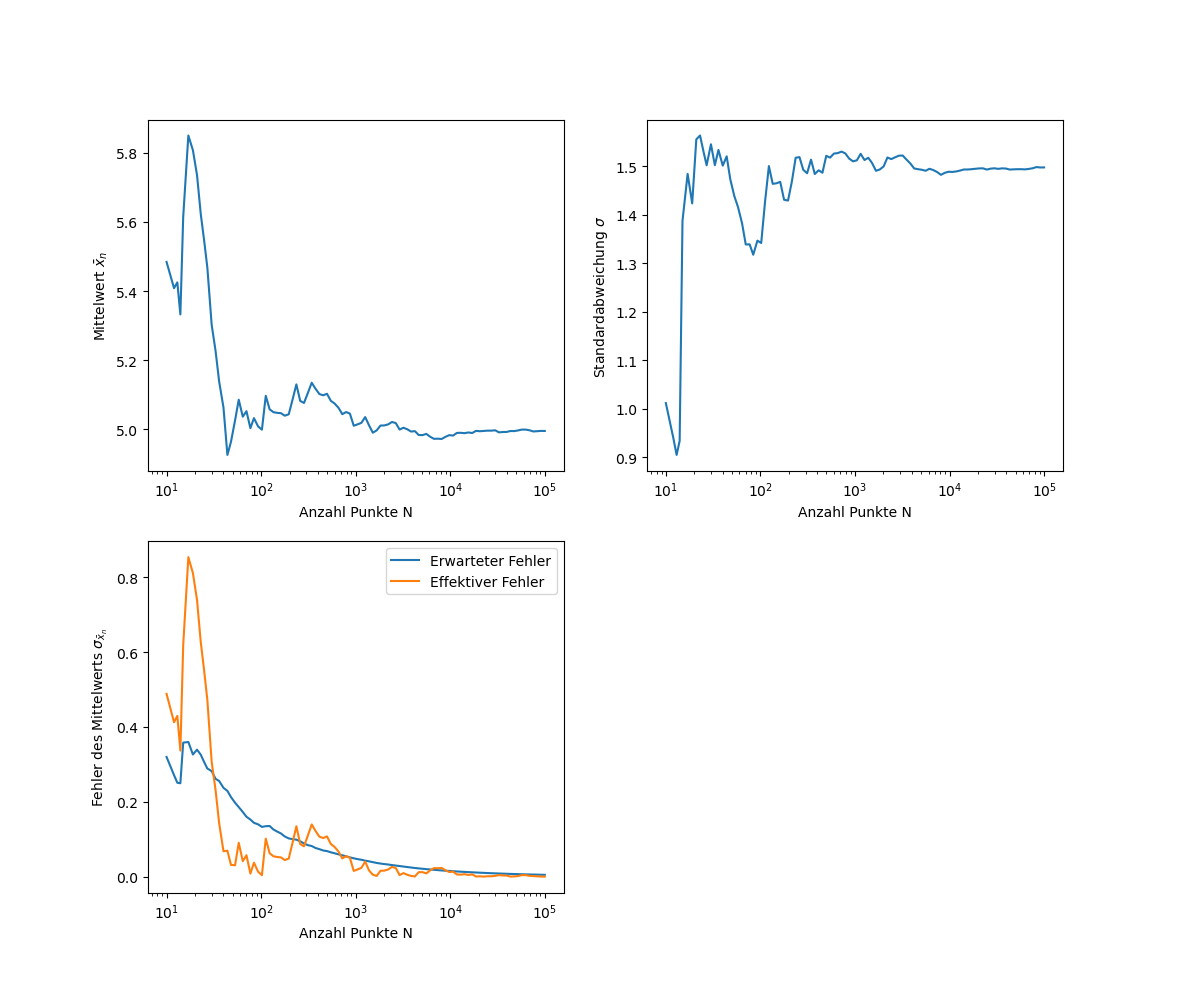

In [4]:
cm = 0.393701  # Umrechnung Zoll zu Centimeter

# Logarithmischer Bereich von 10 bis len(data): Das sind die verschiedenen n (Anzahl berücksichtiger Punkte)
# dtype = int ist notwendig, damit wir diese Zahlen gleich als Arrayindizes verwenden können.
n_points = np.logspace(1, np.log10(len(data)), 100, dtype=int)

# Initialisiere Arrays, in denen die berechneten Werte für jedes n gespeichert werden
mean_n = np.zeros(len(n_points))
std_n = np.zeros(len(n_points))
error_mean = np.zeros(len(n_points))

# Berechne Mittelwert, Standardabweichung und Fehler des Mittelwerts für jedes n.
for i, n in enumerate(n_points):
    mean_n[i] = np.mean(data[:n])
    std_n[i] = np.std(data[:n])
    error_mean[i] = np.std(data[:n]) / np.sqrt(n)

# Ergebnis Plotten
fig = plt.figure(figsize=(30*cm, 25.5*cm))
ax = fig.add_subplot(2, 2, 1)
ax.semilogx(n_points, mean_n)
ax.set_xlabel('Anzahl Punkte N')
ax.set_ylabel(r'Mittelwert $\bar{x}_n$')

ax = fig.add_subplot(2, 2, 2)
ax.semilogx(n_points, std_n)
ax.set_xlabel('Anzahl Punkte N')
ax.set_ylabel(r'Standardabweichung $\sigma$')

ax = fig.add_subplot(2, 2, 3)
ax.semilogx(n_points, error_mean, label='Erwarteter Fehler')
ax.semilogx(n_points, np.abs(mean_n - mean_n[-1]),label='Effektiver Fehler')
ax.set_xlabel('Anzahl Punkte N')
ax.set_ylabel(r'Fehler des Mittelwerts $\sigma_{\bar{x}_n}$')
ax.legend()

Man kann deutlich erkennen, wie sich der Mittelwert und die Standardabweichung der Daten den Werten $\mu=5$ und $\sigma=1.5$ annähern, während die Unsicherheit des Mittelwerts mit $\frac{1}{\sqrt{N}}$ abnimmt. 

## c)

Vergleichen Sie die Mittelwerte und deren Unsicherheiten mit den Verteilungen der Datenpunkte. Plotten Sie dazu die Histogramme für 10, 100, 1'000 und 10'000 Punkte, und zeichnen Sie die dazugehörigen Mittelwerte mit deren Unsicherheiten ein.

### Lösung

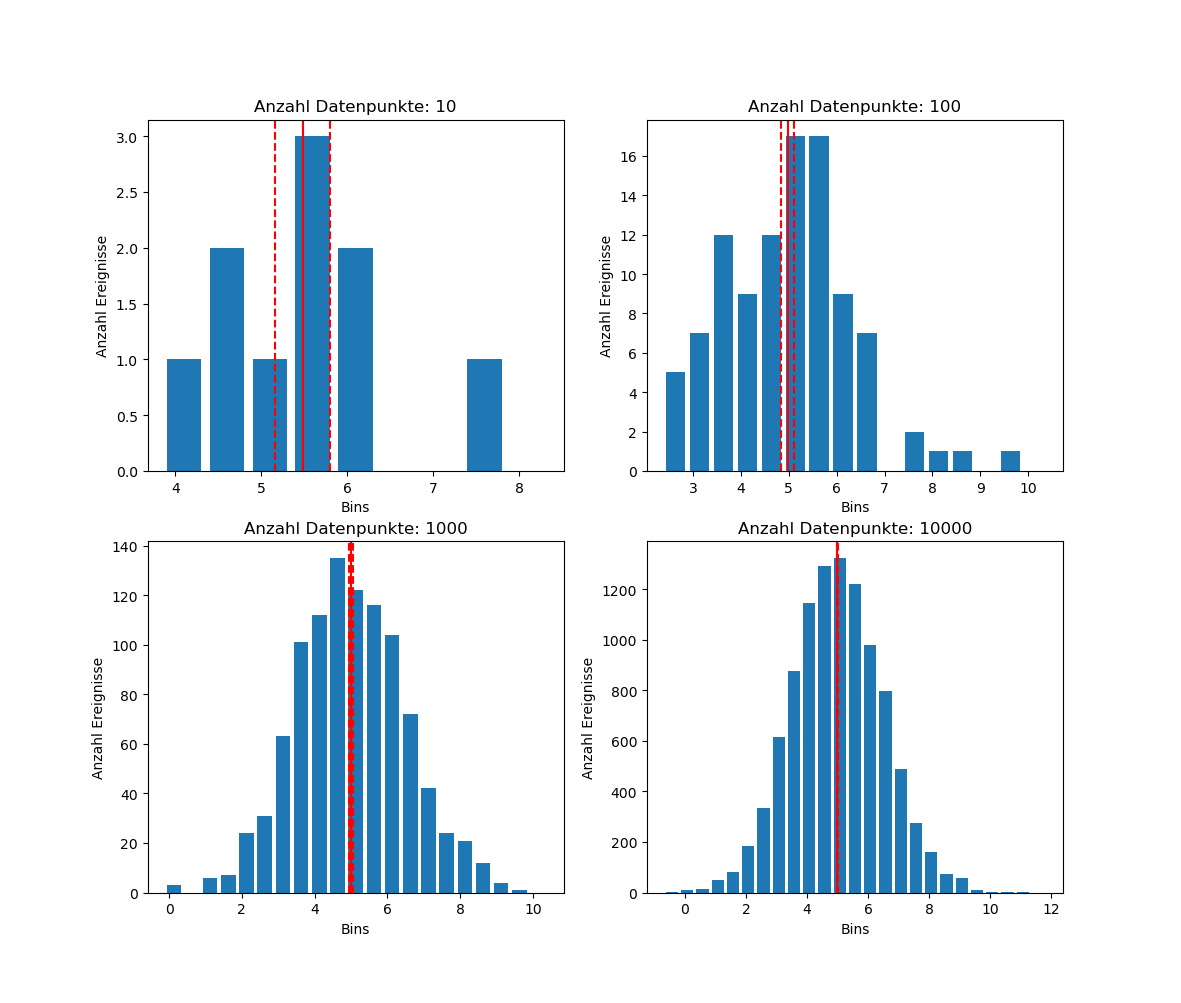

In [5]:
cm = 0.393701  # Umrechnung Zoll zu Zentimeter

# Liste der betrachteten n
n_points_list = np.array([10, 100, 1000, 10000])

fig = plt.figure(figsize=(30*cm, 25.5*cm))
binsize = 0.5

# Wir erzeugen die Histogramme und Plots für die verschiedenen n in einer for-Schleife, da
# der Code immer der gleiche ist.
for i, n_points in enumerate(n_points_list):
    # Mittelwert und Fehler des Mittelwerts berechnen
    mean = np.mean(data[:n_points])
    error_mean = np.std(data[:n_points]) / np.sqrt(n_points)
    
    # Histogramm erzeugen
    bin_edges = np.arange(np.min(data[:n_points]), np.max(data[:n_points])+1, binsize)
    bin_centers = bin_edges[:-1] + 0.5 * binsize
    hist, _ = np.histogram(data[:n_points], bin_edges)
    
    # Plotten
    ax = fig.add_subplot(2, 2, i+1)
    ax.bar(bin_centers, hist, width=0.8*binsize)
    ax.axvline(mean, color='r')
    ax.axvline(mean-error_mean, color='r', linestyle='--')
    ax.axvline(mean+error_mean, color='r', linestyle='--')
    ax.set_xlabel('Bins')
    ax.set_ylabel('Anzahl Ereignisse')
    ax.set_title('Anzahl Datenpunkte: {:.0f}'.format(n_points))

# Aufgabe 2 Fehler des Mittelwerts mit Gauss

Leiten Sie die Unsicherheit des Mittelwerts mithilfe der Gaussschen Fehlerfortpflanzung her. Nehmen Sie dazu an, dass alle Datenpunkte die gleiche Unsicherheit $\sigma$ haben.

### Lösung

Der Mittelwert ist gegeben durch

$$\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i.$$

Jeder Datenpunkt $x_i$ ist eine Unabhähngige Variable, d.h. die Varianz des Mittelwerts ist

$$\sigma_\bar{x}^2 = \sum_{i=1}^{N} \left(\frac{\partial\bar{x}}{\partial x_i}\right)^2 \sigma^2.$$

Die Ableitung nach dem $i$-ten Punkt ist 

$$\left(\frac{\partial\bar{x}}{\partial x_i}\right) = \frac{1}{N},$$

also haben wir

$$\sigma_\bar{x}^2 = \sum_{i=1}^{N} \left(\frac{\partial\bar{x}}{\partial x_i}\right)^2 \sigma^2 = \sum_{i=1}^{N} \frac{1}{N^2} \sigma^2 = \frac{\sigma^2}{N}$$

und somit wie erwartet

$$\sigma_\bar{x} = \frac{\sigma}{\sqrt{N}}.$$

# Aufgabe 3 Gausssche Fehlerfortpflanzung

In vielen Experimenten wird nicht die gesuchte Grösse direkt gemessen, sondern diese muss erst aus den gesammelten Daten berechnet werden. In dieser Aufgabe werden Sie die Fehler einer solchen Grösse durch Fehlerfortpflanzung der Unsicherheit normalverteilter Werte berechnen.

Als System betrachten wir dazu eine Masse $m$, die sich mit einer Geschwindigkeit $v$ auf einer Kreisbahn mit Radius $R$ bewegt. Nun soll für verschiedene Geschwindigkeiten die Kraft berechnet werden, mit der die Masse auf der Kreisbahn gehalten wird. Die Geschwindigkeiten und ihre Standardabweichungen können dabei aus der Datei `Geschwindigkeiten.txt` entnommen werden. Die zusätzlichen Werte sind:

$m$  | $R$
---|---
0.1 $\pm$ 0.001 kg| 0.15 $\pm$ 0.001 m

## a)

Laden Sie zuerst den Datensatz.

### Lösung

In [6]:
R = 0.15
sigma_R = 0.001
m = 0.1
sigma_m = 0.001

data = np.loadtxt('Geschwindigkeiten.txt')
v = data[0,:]
sigma_v = data[1,:]

## b)

Berechnen Sie nun die Unsicherheit der Zentripetalkraft mit der Gaussschen Fehlerfortpflanzung. Vergleichen Sie die einzelnen Terme in der Summe. Gibt es Terme, die Sie vernachlässigen können?

Tipp: Sie können mit `ax.set_yscale` auf eine logarithmische Skala auf der y-Achse wechseln.

### Lösung

Die Zentripetalkraft ist gegeben durch $F_z=\frac{mv^2}{R}$, woraus die Unsicherheit

$$\sigma_F=\sqrt{\left(\frac{\partial F}{\partial m}\right)^2\sigma_m^2 + \left(\frac{\partial F}{\partial v}\right)^2\sigma_v^2+\left(\frac{\partial F}{\partial R}\right)^2\sigma_R^2} = \sqrt{\frac{v^4}{R^2}\sigma_m^2 + \frac{4m^2v^2}{R^2}\sigma_v^2 + \frac{m^2v^4}{R^4}\sigma_R^2} = F_z\sqrt{\frac{1}{m^2}\sigma_m^2+\frac{4}{v^2}\sigma_v^2+\frac{1}{R^2}\sigma_R^2}$$

folgt. Wir vergleichen nun die Terme unter der Wurzel:

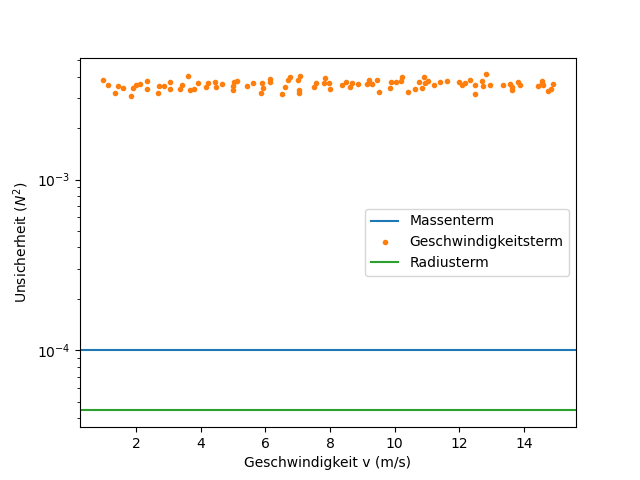

In [7]:
dFdm = 1 / m**2 * sigma_m**2
dFdv = 4 / v**2 * sigma_v**2
dFdR = 1 / R**2 * sigma_R**2

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

# Logarithmische Skalierung der y-Achse
ax.set_yscale("log", nonpositive='clip')
ax.axhline(dFdm, color='C0', label='Massenterm')
ax.plot(v, dFdv, '.', color='C1', label='Geschwindigkeitsterm')
ax.axhline(dFdR, color='C2', label='Radiusterm')
ax.set_xlabel('Geschwindigkeit v (m/s)')
ax.set_ylabel(r'Unsicherheit $(N^2)$')
ax.legend()

Der Fehler des Radius ist im vergleich zu den anderen beiden Termen vernachlässigbar klein. Was also übrig bleibt ist:
$\sigma_F = F_z\sqrt{\frac{1}{m^2}\sigma_m^2+\frac{4}{v^2}\sigma_v^2}$.

## c)

Plotten Sie nun die Kraft zusammen mit den Fehlern in Abhängigkeit der gemessenen Geschwindigkeit. Sie können dazu `ax.errorbar()` benutzen. 

### Lösung

Text(0.5, 1.0, 'Zentripetalkraft')

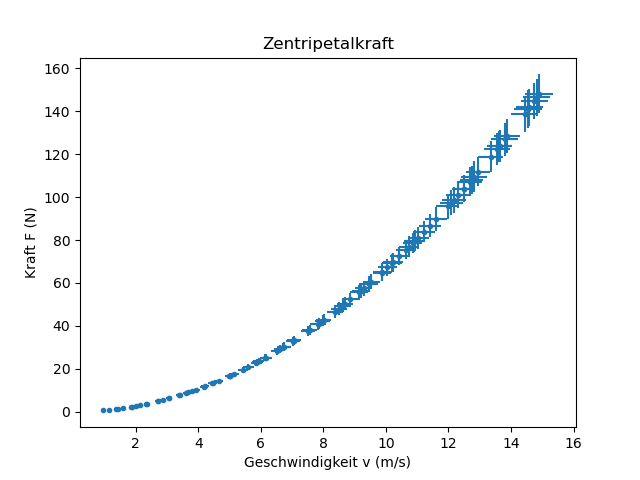

In [8]:
Fz = m * v**2 / R
sigma_F = Fz * np.sqrt(1 / m**2 * sigma_m**2 + 4 / v**2 * sigma_v**2)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(v, Fz, xerr=sigma_v, yerr=sigma_F, marker='.', linestyle='none')
ax.set_xlabel('Geschwindigkeit v (m/s)')
ax.set_ylabel('Kraft F (N)')
ax.set_title('Zentripetalkraft')

## Aufgabe 4 Gausssche Fehlerfortpflanzung

Wir betrachten den exponentiellen Zerfall der Population eines beliebigen Systems (z.B. eines radioaktiven Isotops), gegeben durch $N(t) = N_0e^{-\frac{t}{\tau}}$. Um die Zerfallszeit $\tau$ zu bestimmen, wird wiederholt die Anfangspopulation $N_0$ und die Population $N(t)$ nach einer Zeit $t$ gemessen.

## a)

Berechnen Sie die Unsicherheit $\sigma_\tau$ der Zerfallszeit abhängig von den Unsicherheiten der Population ($\sigma_N$) und der gemessenen Zeit ($\sigma_t$).

### Lösung

Zuerst formen wir die Gleichung um und lösen nach $\tau$ auf:

$$ \tau = \frac{t}{ln\left(\frac{N_0}{N(t)}\right)}.$$

Anschliessend können wir die Unsicherheit berechnen, wobei wir annehmen dass $\sigma_N=\sigma_{N_0}$:

$$\sigma_\tau=\sqrt{\left(\left(\frac{\partial\tau}{\partial N}\right)^2+\left(\frac{\partial\tau}{\partial N_0}\right)^2\right)\sigma_N^2 + \left(\frac{\partial\tau}{\partial t}\right)^2\sigma_t^2}.$$

Die Ableitungen sind

$$\frac{\partial\tau}{\partial t} = \frac{1}{ln\left(\frac{N_0}{N(t)}\right)},$$

$$\frac{\partial\tau}{\partial N_0} = -\frac{t}{ln^2\left(\frac{N_0}{N}\right)N_0},$$

$$\frac{\partial\tau}{\partial N} = \frac{t}{ln^2\left(\frac{N_0}{N}\right)N}.$$

Einsetzen ergibt schliesslich

$$\sigma_\tau=\sqrt{\left(\frac{t^2}{ln^4\left(\frac{N_0}{N}\right)N^2}+\frac{t^2}{ln^4\left(\frac{N_0}{N}\right)N_0^2}\right)\sigma_N^2 + \frac{1}{ln^2\left(\frac{N_0}{N}\right)}\sigma_t^2} = \tau \sqrt{\left(\frac{1}{ln^2\left(\frac{N_0}{N}\right)N^2}+\frac{1}{ln^2\left(\frac{N_0}{N}\right)N_0^2}\right)\sigma_N^2+\frac{1}{t^2}\sigma_t^2}.$$



## b)

Laden Sie nun die Datensätze `Population1.txt` und `Population2.txt`. Sie beinhalten die wiederholte Messung von $N_0$ sowie $N(t=20s)$, wobei der zweite Datensatz mit einem Detektor mit einer grösseren Unsicherheit gemessen wurde. Nehmen Sie an, dass die Unsicherheit in der Zeit vernachlässigbar ist, und plotten Sie die Histogramme der Zerfallskonstanten. Was können Sie beobachten?

### Lösung

In [9]:
t = 20

data = np.loadtxt('Population1.txt', comments='#')
N01 = data[0, :]
N1 = data[1, :]

data = np.loadtxt('Population2.txt', comments='#')
N02 = data[0, :]
N2 = data[1, :]

Text(0.5, 1.0, 'Hohe Unsicherheit')

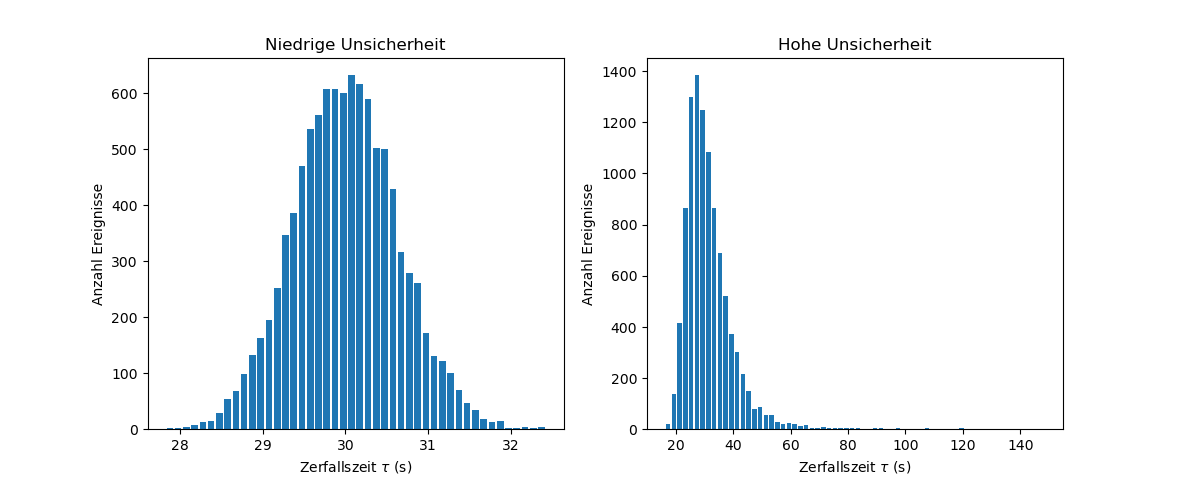

In [10]:
tau1 = t / np.log(N01 / N1)
tau2 = t / np.log(N02 / N2)

# Histogramme berechnen
binsize1 = 0.1
bin_edges1 = np.arange(np.min(tau1), np.max(tau1), binsize1)
bin_centers1 = bin_edges1[:-1] + 0.5 * binsize1
hist1, _ = np.histogram(tau1, bin_edges1)

binsize2 = 2
bin_edges2 = np.arange(np.min(tau2), np.max(tau2), binsize2)
bin_centers2 = bin_edges2[:-1] + 0.5 * binsize2
hist2, _ = np.histogram(tau2, bin_edges2)

# Daten plotten
cm = 0.393701  # Umrechnung Zoll zu Centimeter

fig = plt.figure(figsize=(30*cm, 12.25*cm))
ax = fig.add_subplot(1, 2, 1)
ax.bar(bin_centers1, hist1, width=0.8*binsize1)
ax.set_xlabel('Zerfallszeit $\\tau$ (s)')
ax.set_ylabel('Anzahl Ereignisse')
ax.set_title('Niedrige Unsicherheit')

ax = fig.add_subplot(1, 2, 2)
ax.bar(bin_centers2, hist2, width=0.8*binsize2)
ax.set_xlabel('Zerfallszeit $\\tau$ (s)')
ax.set_ylabel('Anzahl Ereignisse')
ax.set_title('Hohe Unsicherheit')

Mit der Gaussschen Fehlerforpflanzung benutzt man die lokale Steigung der Funktion um die Unsicherheit zu skalieren. Ist die Unsicherheit aber zu gross, bricht die lineare Approximation zusammen und man erhält keine Normalverteilung mehr, sondern eine asymmetrische Verteilung wie im Histogramm rechts zu sehen.